### RaschPy global MFRM worked example

This notebook works through a sample Rasch analysis of a simulated data set (200 persons, 8 items with a maximum score of 5, all rated by 8 raters, no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

In [1]:
import raschpy as rp
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if it's disconnected — if there's no chain of persons and items linking every item to every other, the resulting item locations aren't on a common scale, even though `calibrate()` will still run without error. This is worth seeing happen once. Here we build a small, deliberately disconnected data set: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.MFRM_Sim_Global(no_of_items=8, no_of_persons=40, no_of_raters=4, max_score=5, seed=99)
responses_disconnected = sim_disconnected.responses.copy()
persons = responses_disconnected.index.get_level_values(1).unique()
group_a, group_b = persons[:20], persons[20:]
responses_disconnected.loc[(slice(None), group_a), responses_disconnected.columns[4:]] = float('nan')   # group A: only items 1-4
responses_disconnected.loc[(slice(None), group_b), responses_disconnected.columns[:4]] = float('nan')    # group B: only items 5-8

broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/mfrm.py:341: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 4): ['Item_1', 'Item_2', 'Item_3', 'Item_4']; Sub-group 2 (size 4): ['Item_5', 'Item_6', 'Item_7', 'Item_8']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_52545/186247924.py:8: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_mfrm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4'],
  ['Item_5', 'Item_6', 'Item_7', 'Item_8']],
 'directionally_isolated_items': []}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=42` makes the simulation fully reproducible — rerunning this notebook will always generate the same data set.

In [4]:
sim = rp.MFRM_Sim_Global(no_of_items=8, no_of_persons=200, no_of_raters=8, max_score=5, missing=0, seed=42)
sim.responses.to_csv('mfrm_global_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_mfrm_single()` to load and validate it (for a single file with a (Rater, Person) MultiIndex — see `loadup_mfrm_xlsx_tabs()`/`loadup_mfrm_multiple()` for one-sheet-per-rater or one-file-per-rater layouts). Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_mfrm_single('mfrm_global_scores.csv', max_score=5)

Check the data - view the first two lines

In [6]:
data.head(2)

Item_1  Item_2  Item_3  Item_4  Item_5  Item_6  Item_7  \
Rater   Person                                                             
Rater_1 Person_1     3.0     5.0     4.0     3.0     5.0     4.0     3.0   
        Person_2     3.0     1.0     2.0     2.0     2.0     4.0     2.0   

                  Item_8  
Rater   Person            
Rater_1 Person_1     2.0  
        Person_2     1.0

Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8
Rater,Person,,,,,,,,


Create an MFRM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `mfrm.generating`, which lets us check parameter recovery further down. If you're analysing your own data, pass a DataFrame instead (e.g. `rp.MFRM(data)`).

In [8]:
mfrm = rp.MFRM(sim)

Calibrate under the global rater parameterisation (a single scalar severity per rater). The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
mfrm.calibrate_global()

CPU times: user 2.36 ms, sys: 232 μs, total: 2.59 ms
Wall time: 2.47 ms


Check the item location estimates - view the first two items

In [10]:
mfrm.items.head(2)

Item_1   -1.07546
Item_2   -0.41129
dtype: float64

Since this is simulated data, we know the true generating item locations and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) — the closer the points hug the identity line, the better the recovery — alongside the Pearson correlation, SD ratio, regression coefficient, and RMSE:

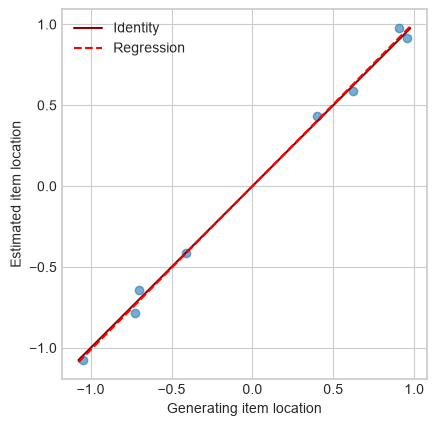

item location Pearson correlation:              0.998
item location SD ratio (estimated / generating): 1.014
item location regression coefficient:            1.012
item location RMSE:                              0.045


In [11]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:              {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                              {round(np.sqrt(((x - y) ** 2).mean()), 3)}')

recovery_plot(sim.items, mfrm.items, 'item location', 'my_mfrm_global_item_recovery.png')

Generate a table of item statistics (and check run time), and save to file

In [12]:
%%time
mfrm.item_stats_df_global()
mfrm.item_stats_global.to_csv('mfrm_global_item_stats.csv')

CPU times: user 2.74 s, sys: 52.5 ms, total: 2.79 s
Wall time: 2.8 s


Check the item statistics table - view the first two items

In [13]:
mfrm.item_stats_global.head(2)

,Estimate,SE,Count,Facility,Infit MS,Outfit MS
Item_1,-1.075,0.043,1600,0.650,0.959,0.962
Item_2,-0.411,0.032,1600,0.569,1.036,1.034


Generate a table of threshold statistics (and check run time), and save to file

In [14]:
%%time
mfrm.threshold_stats_df_global()
mfrm.threshold_stats_global.to_csv('mfrm_global_threshold_stats.csv')

CPU times: user 52.3 ms, sys: 1.45 ms, total: 53.8 ms
Wall time: 53.7 ms


Check the threshold statistics table - view the first two thresholds

In [15]:
mfrm.threshold_stats_global.head(2)

,Estimate,SE,Infit MS,Outfit MS
Threshold 1,-2.244,0.072,1.030,1.049
Threshold 2,-1.751,0.042,0.981,1.001


And the same recovery check for thresholds, against `sim.thresholds`:

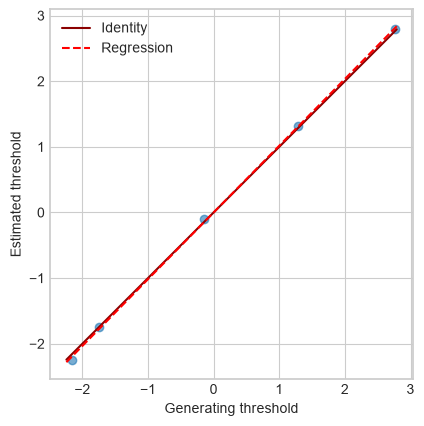

threshold Pearson correlation:              1.0
threshold SD ratio (estimated / generating): 1.017
threshold regression coefficient:            1.017
threshold RMSE:                              0.047


In [16]:
recovery_plot(sim.thresholds, mfrm.thresholds, 'threshold', 'my_mfrm_global_threshold_recovery.png')

Generate a table of rater statistics (and check run time), and save to file

In [17]:
%%time
mfrm.rater_stats_df_global()
mfrm.rater_stats_global.to_csv('mfrm_global_rater_stats.csv')

CPU times: user 25.5 ms, sys: 797 μs, total: 26.3 ms
Wall time: 26.1 ms


Check the rater statistics table - view the first two raters

In [18]:
mfrm.rater_stats_global.head(2)

,Estimate,SE,Count,Infit MS,Outfit MS
Rater_1,-0.884,0.043,1600,1.012,1.004
Rater_2,0.921,0.046,1600,1.019,1.035


And the same recovery check for rater severities, against `sim.facet_effects`:

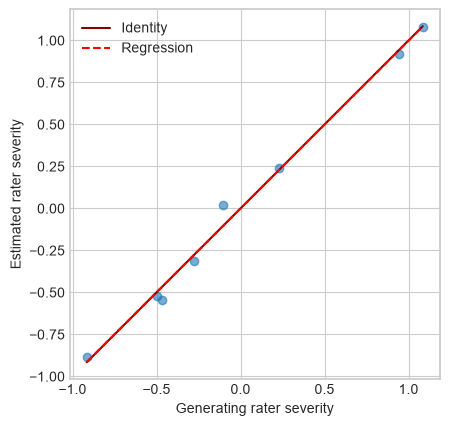

rater severity Pearson correlation:              0.996
rater severity SD ratio (estimated / generating): 1.002
rater severity regression coefficient:            0.998
rater severity RMSE:                              0.056


In [19]:
recovery_plot(sim.facet_effects, mfrm.raters_global, 'rater severity', 'my_mfrm_global_rater_recovery.png')

Generate a table of person statistics (and check run time), and save to file

In [20]:
%%time
mfrm.person_stats_df_global()
mfrm.person_stats_global.to_csv('mfrm_global_person_stats.csv')

CPU times: user 8.69 ms, sys: 595 μs, total: 9.28 ms
Wall time: 9.24 ms


Check the person statistics table - view the first two persons

In [21]:
mfrm.person_stats_global.head(2)

,Estimate,CSEM,Score,Max score,p,Infit MS,Outfit MS
Person_1,0.529,0.152,188,320,0.588,1.151,1.143
Person_2,-1.331,0.149,104,320,0.325,1.242,1.353


And the same recovery check for person locations, against `sim.persons`:

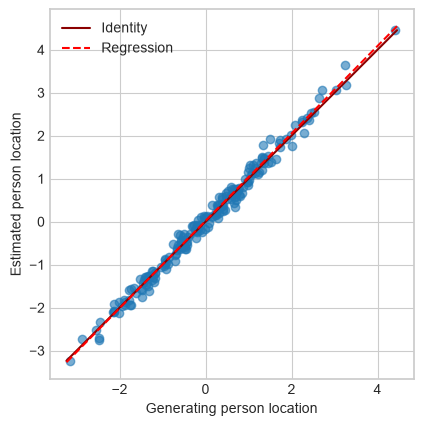

person location Pearson correlation:              0.995
person location SD ratio (estimated / generating): 1.022
person location regression coefficient:            1.017
person location RMSE:                              0.143


In [22]:
recovery_plot(sim.persons, mfrm.persons_global, 'person location', 'my_mfrm_global_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [23]:
%%time
mfrm.test_stats_df_global()
mfrm.test_stats_global.to_csv('mfrm_global_test_stats.csv')

CPU times: user 1.79 ms, sys: 386 μs, total: 2.18 ms
Wall time: 2.17 ms


Check the test statistics table

In [24]:
mfrm.test_stats_global

,Items,Persons
Mean,0.000,0.019
SD,0.818,1.352
Separation ratio,20.381,8.604
Strata,27.508,11.805
Reliability,0.998,0.987


Run an item residual correlation analysis (and check run time), and save relevant output to file

In [25]:
%%time
mfrm.item_res_corr_analysis_global()
mfrm.item_residual_correlations_global.to_csv('mfrm_global_item_residual_correlations.csv')
mfrm.item_loadings_global.to_csv('mfrm_global_item_loadings.csv')

CPU times: user 4.74 ms, sys: 1.51 ms, total: 6.25 ms
Wall time: 6.78 ms


View the table of pairwise item standard residual correlations

In [26]:
mfrm.item_residual_correlations_global

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8
Item_1,1.000000,-0.002218,0.010519,-0.035305,-0.012743,-0.011523,-0.063302,-0.030411
Item_2,-0.002218,1.000000,0.001468,0.002267,-0.026595,-0.029239,-0.006840,0.006619
Item_3,0.010519,0.001468,1.000000,-0.006932,0.020007,0.002017,-0.016358,-0.035317
Item_4,-0.035305,0.002267,-0.006932,1.000000,0.029347,-0.041142,0.026909,-0.033027
Item_5,-0.012743,-0.026595,0.020007,0.029347,1.000000,-0.056603,-0.007647,0.013933
Item_6,-0.011523,-0.029239,0.002017,-0.041142,-0.056603,1.000000,-0.024285,0.004640
Item_7,-0.063302,-0.006840,-0.016358,0.026909,-0.007647,-0.024285,1.000000,-0.028295
Item_8,-0.030411,0.006619,-0.035317,-0.033027,0.013933,0.004640,-0.028295,1.000000


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [27]:
mfrm.item_loadings_global['PC 1']

Item_1   -0.185674
Item_2   -0.013667
Item_3   -0.046607
Item_4    0.210653
Item_5    0.124750
Item_6   -0.192592
Item_7    0.193649
Item_8   -0.065851
Name: PC 1, dtype: float64

Run a rater residual correlation analysis (and check run time), and save relevant output to file

In [28]:
%%time
mfrm.rater_res_corr_analysis_global()
mfrm.rater_residual_correlations_global.to_csv('mfrm_global_rater_residual_correlations.csv')
mfrm.rater_loadings_global.to_csv('mfrm_global_rater_loadings.csv')

CPU times: user 8.5 ms, sys: 639 μs, total: 9.14 ms
Wall time: 9.12 ms


View the table of pairwise rater standard residual correlations

In [29]:
mfrm.rater_residual_correlations_global

,Rater_1,Rater_2,Rater_3,Rater_4,Rater_5,Rater_6,Rater_7,Rater_8
Rater_1,1.000000,0.000015,0.016193,-0.022844,-0.028662,-0.021162,-0.002590,0.007060
Rater_2,0.000015,1.000000,-0.030892,0.013851,-0.023422,-0.012861,-0.003917,-0.041135
Rater_3,0.016193,-0.030892,1.000000,0.004037,-0.025463,-0.044031,-0.036333,-0.000754
Rater_4,-0.022844,0.013851,0.004037,1.000000,-0.055319,-0.005457,-0.030980,-0.017965
Rater_5,-0.028662,-0.023422,-0.025463,-0.055319,1.000000,-0.012669,-0.049144,0.015152
Rater_6,-0.021162,-0.012861,-0.044031,-0.005457,-0.012669,1.000000,-0.021041,-0.032412
Rater_7,-0.002590,-0.003917,-0.036333,-0.030980,-0.049144,-0.021041,1.000000,0.042314
Rater_8,0.007060,-0.041135,-0.000754,-0.017965,0.015152,-0.032412,0.042314,1.000000


View the rater loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [30]:
mfrm.rater_loadings_global['PC 1']

Rater_1    0.070567
Rater_2   -0.156471
Rater_3   -0.001231
Rater_4   -0.208686
Rater_5    0.102169
Rater_6   -0.140416
Rater_7    0.133360
Rater_8    0.221175
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) curve for Item 2, with observed category means plotted and the central item location marked

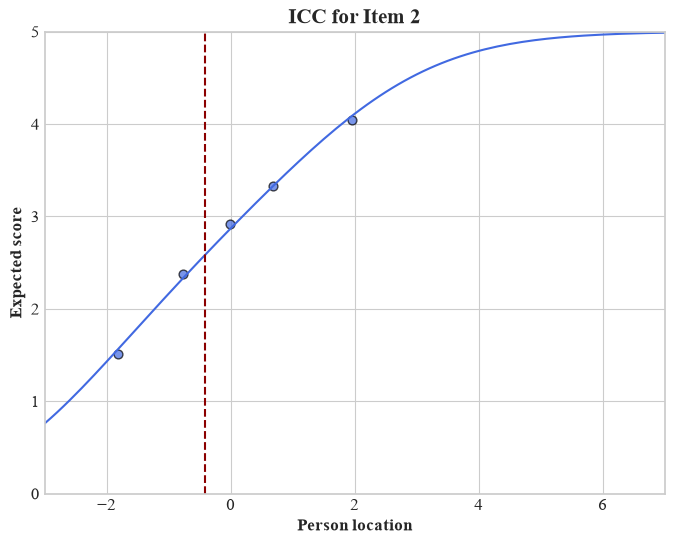

In [31]:
mfrm.icc_global('Item_2', title='ICC for Item 2', obs=True, central_location=True, cat_highlight=3, xmin=-3, xmax=7, filename='my_mfrm_global_icc')

Produce a set of category response curves for Item 2, with category 1 highlighted and the thresholds marked

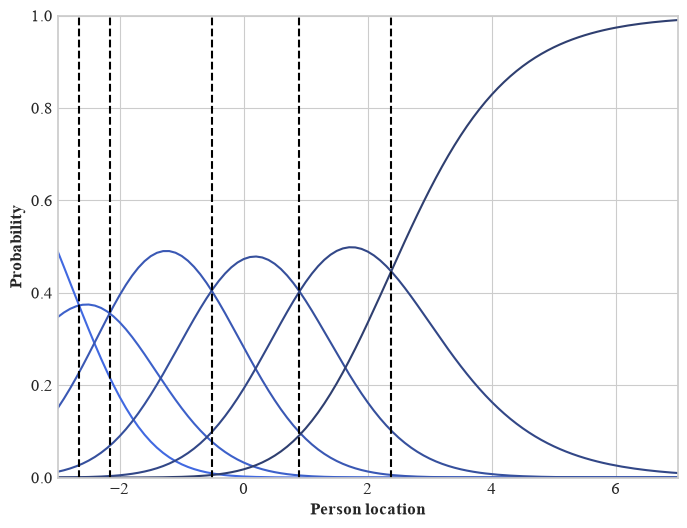

In [32]:
mfrm.crcs_global('Item_2', thresh_lines=True, cat_highlight=1, xmin=-3, xmax=7, filename='my_mfrm_global_crcs')

Produce a set of threshold characteristic curves for Item 2, with observed category means plotted for threshold 5, category 1 highlighted and the thresholds marked

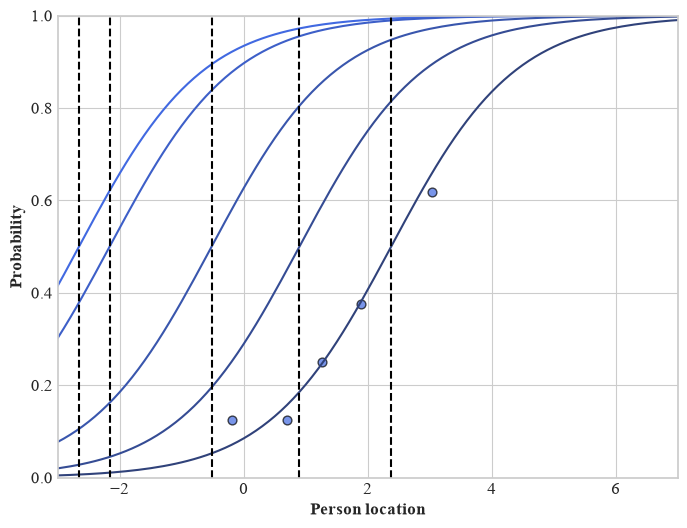

In [33]:
mfrm.threshold_ccs_global('Item_2', thresh_lines=True, obs=[5], cat_highlight=1, xmin=-3, xmax=7, filename='my_mfrm_global_threshold_ccs')

Produce an item information function curve for Item 2

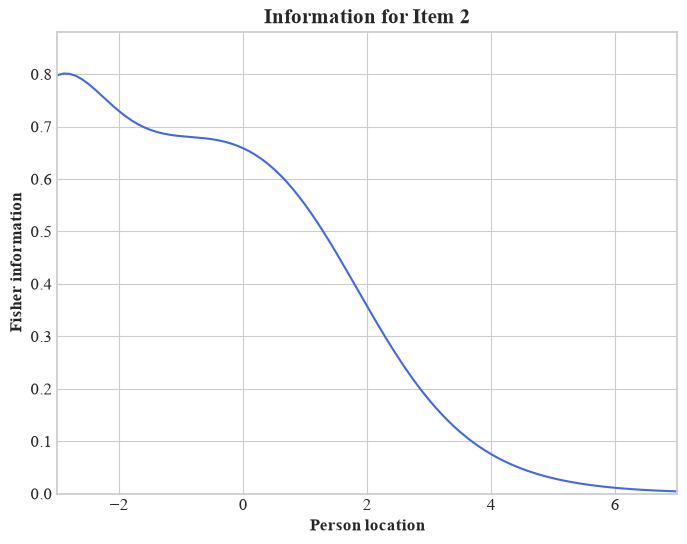

In [34]:
mfrm.iic_global('Item_2', title='Information for Item 2', xmin=-3, xmax=7, filename='my_mfrm_global_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 20 and 30 plotted.

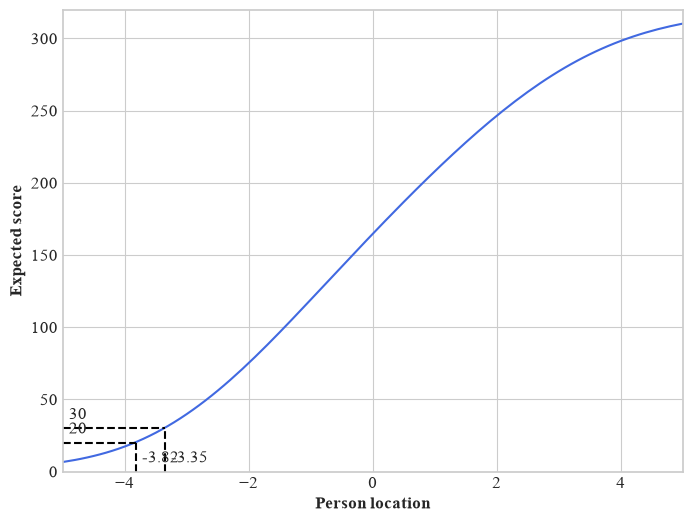

In [35]:
mfrm.tcc_global(score_lines=[20, 30], score_labels=True, filename='my_mfrm_global_tcc')

Produce a test information curve

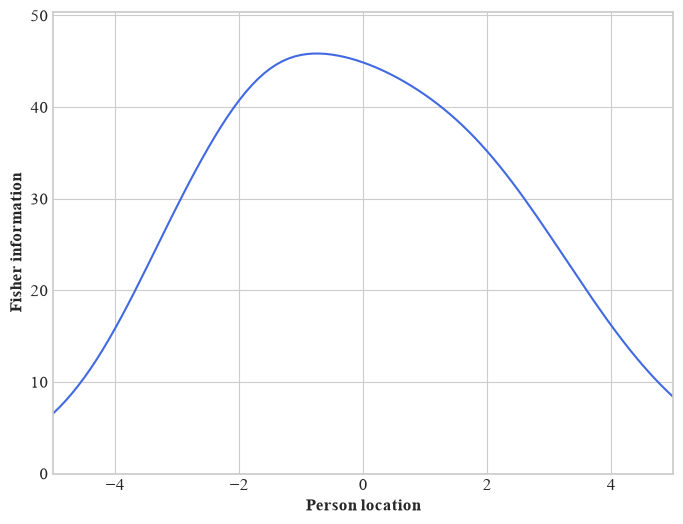

In [36]:
mfrm.test_info_global(filename='my_mfrm_global_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

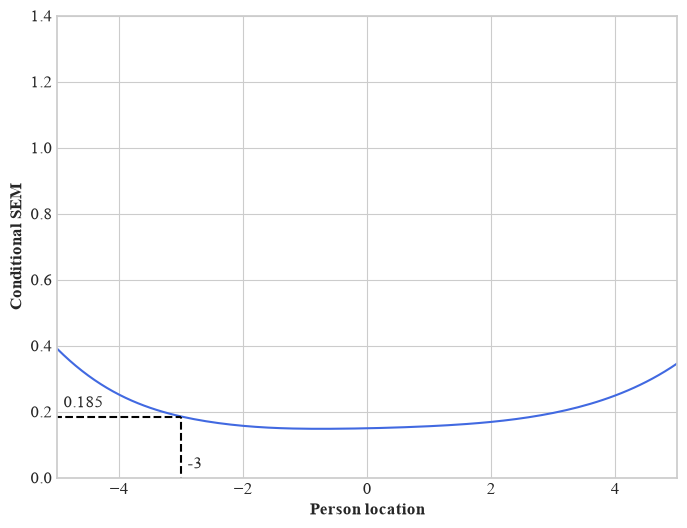

In [37]:
mfrm.test_csem_global(point_csem_lines=[-3], point_csem_labels=True, ymax=1.4, filename='my_mfrm_global_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

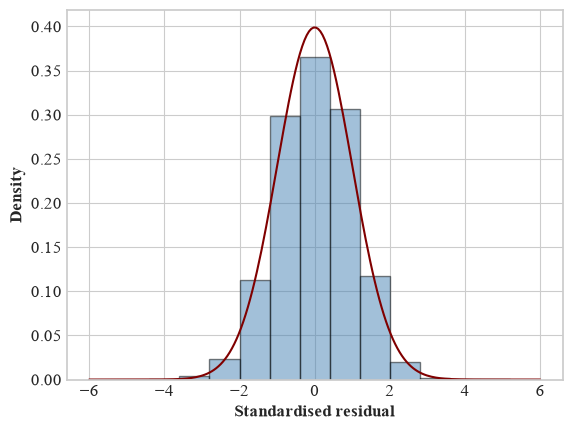

In [38]:
mfrm.std_residuals_plot_global(bin_width=0.6, normal=True, filename='my_mfrm_global_std_residuals_plot')

Now run an anchored analysis, anchoring to the mean severity of Raters 1-4 (e.g. a set of 'gold standard' raters).

In [39]:
%%time
anchors = ['Rater_1', 'Rater_2', 'Rater_3', 'Rater_4']
mfrm.calibrate_global_anchor(anchors)

CPU times: user 582 μs, sys: 89 μs, total: 671 μs
Wall time: 612 μs


Check the anchored rater severities against the unanchored ones.

In [40]:
mfrm.anchor_raters_global

Rater_1   -0.678262
Rater_2    1.125912
Rater_3   -0.105805
Rater_4   -0.341845
Rater_5    0.223474
Rater_6    0.447512
Rater_7    1.286839
Rater_8   -0.315069
dtype: float64

In [41]:
mfrm.raters_global

Rater_1   -0.883607
Rater_2    0.920567
Rater_3   -0.311149
Rater_4   -0.547190
Rater_5    0.018130
Rater_6    0.242168
Rater_7    1.081494
Rater_8   -0.520413
dtype: float64